# Industrial Predictive Analytics Pipeline

## Objective
Build an end-to-end machine learning workflow for industrial sensor analytics.

## Features
- Data preprocessing
- Anomaly detection using Isolation Forest
- Predictive modelling using Random Forest
- Performance evaluation using RMSE

## Technologies
- Python
- Pandas
- Scikit-learn
- Matplotlib

Author: Parag Gupta



In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
import pandas as pd

data = {
    'temperature': [45, 47, 49, 50, 52, 150, 48, 46, 47, 200],
    'pressure': [100, 101, 99, 102, 98, 300, 100, 101, 99, 350],
    'output': [80, 82, 85, 84, 86, 20, 83, 81, 82, 15]
}

df = pd.DataFrame(data)

print(df)

   temperature  pressure  output
0           45       100      80
1           47       101      82
2           49        99      85
3           50       102      84
4           52        98      86
5          150       300      20
6           48       100      83
7           46       101      81
8           47        99      82
9          200       350      15


In [3]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.2, random_state=42)

df['anomaly'] = iso.fit_predict(df[['temperature','pressure']])

print(df)

   temperature  pressure  output  anomaly
0           45       100      80        1
1           47       101      82        1
2           49        99      85        1
3           50       102      84        1
4           52        98      86        1
5          150       300      20       -1
6           48       100      83        1
7           46       101      81        1
8           47        99      82        1
9          200       350      15       -1


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[['temperature','pressure']]
y = df['output']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions)

[82.26 81.43]


In [5]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 0.4430011286667309


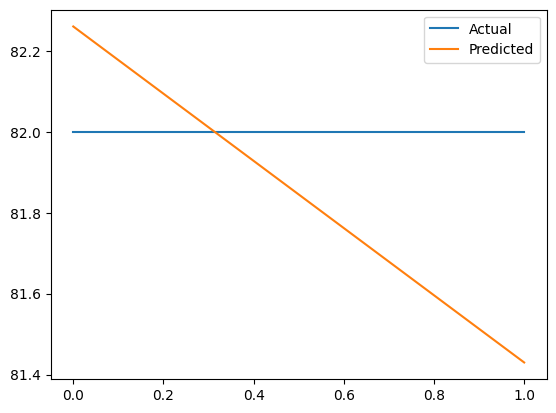

In [6]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()